<a href="https://colab.research.google.com/github/7235SYXD/Real-Estate/blob/main/DSP_on_Real_Estate_(NB_7).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL LIBRARIES                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys
for lib in ["kagglehub","catboost","shap","optuna",
            "vaderSentiment","yake","textstat"]:
    subprocess.run([sys.executable,"-m","pip","install",lib,"-q"])
print("All libraries installed.")

All libraries installed.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GOOGLE DRIVE                                           ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, shutil
from google.colab import drive, files

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/RealEstate_TXNY"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory: /content/drive/MyDrive/RealEstate_TXNY


In [ ]:
# ╔════════════════════════════════════════════════════╗
# ║  CELL 3 — IMPORT ALL LIBRARIES                     ║
# ╚════════════════════════════════════════════════════╝

"""
Imports all libraries and sets global constants.

Global constants set in this cell:
    SEED (42) : This random seed is used for all the operations which helps to ensure
                reproducibility. This random seed is applied to numpy, tensorflow,
                train_test_split, all sklearn models, optuna samplers, KFold splits.

Key imports by category:
    Data wrangling  : numpy, pandas, gc (garbage collection for RAM management)
    Visualisation   : matplotlib.pyplot, seaborn, gridspec
    Preprocessing   : StandardScaler, IterativeImputer (MICE), LabelEncoder
    Models          : RandomForestRegressor, CatBoostRegressor, keras (MLP),
                      HistGradientBoostingRegressor
    Metrics         : r2_score, mean_squared_error, mean_absolute_error,
                      roc_auc_score, f1_score, classification_report
    Tuning          : optuna (TPE sampler, MedianPruner)
    Interpretability: shap (TreeExplainer, permutation_importance)
    NLP             : SentimentIntensityAnalyzer (VADER), yake, textstat

"""

import os
import re
import warnings
from pathlib import Path
import gc # Import the garbage collection module

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib.ticker as mticker

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, f1_score, classification_report,
    accuracy_score,
)

# Gradient boosting
!pip install catboost
from catboost import CatBoostRegressor, CatBoostClassifier
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hyperparameter tuning
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Interpretability
import shap

# NLP
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
!pip install yake
import yake
!pip install textstat
import textstat

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("All libraries imported successfully.")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  tensorflow : {tf.__version__}")
print(f"  sklearn    : OK")
print("=" * 60)

All libraries imported successfully.
  pandas     : 2.2.2
  numpy      : 2.0.2
  tensorflow : 2.20.0
  sklearn    : OK


# Notebook 7 Setup - Restore State from Notebook 6

Restores all the 571 variables produced by all the notebooks (feature
matrices, fitted base + stacked models, encoders, scalers, evaluation
tables, SHAP importances, etc.) from the dill checkpoint, on addition to it any Keras models from their `.keras` files, so that this notebook can continue straight from Cell 32 without re-running any earlier notebook.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 7: SETUP — restores state from Notebook 6              ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Loads 571 variables from the dill checkpoint saved by Notebook 6.

Restore mechanism:
    1. pip install dill (fast, already cached)
    2. Open checkpoint_6_to_7.pkl → dill.load() → globals().update()
       Makes all 571 Notebook 6 variables available in this session.
    3. Open checkpoint_6_to_7_keras.json → for each entry,
       keras.models.load_model(path) → globals()[name] = model

"""

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, json

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
CKPT_NAME = "checkpoint_6_to_7"

with open(f"{CKPT_DIR}/{CKPT_NAME}.pkl", "rb") as f:
    _state = dill.load(f)
globals().update(_state)

with open(f"{CKPT_DIR}/{CKPT_NAME}_keras.json") as f:
    _keras_paths = json.load(f)
for _name, _path in _keras_paths.items():
    globals()[_name] = keras.models.load_model(_path)

print("=" * 65)
print(f"CHECKPOINT RESTORED <- {CKPT_DIR}/{CKPT_NAME}.pkl")
print("=" * 65)
print(f"  Variables restored    : {len(_state)}")
print(f"  Keras models restored : {list(_keras_paths.keys()) or 'none'}")
if "df_combined" in globals():
    print(f"  df_combined shape      : {df_combined.shape}")
print(f"\nNotebook 6 state loaded successfully.")
print("Continuing from Cell 32 below, unchanged.")

CHECKPOINT RESTORED <- /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_6_to_7.pkl
  Variables restored    : 571
  Keras models restored : ['mlp_base_model', 'mlp_tuned', 'mlp_f', 'mlp_bl_m_obj', 'mlp_clf']
  df_combined shape      : (119979, 51)

Notebook 6 state loaded successfully.
Continuing from Cell 32 below, unchanged.


# Cell 32 - SHAP Feature Importance (CatBoost)

The tuned CatBoost model run SHAP TreeExplainer this is choosen because it's the single base model and TreeExplainer which is strongest and gives exact not the sampling-based SHAP values for tree ensembles.

- **Plot 1:** SHAP beeswarm — The direction and magnitude of each feature's
  contribution across 3,000 sampled test predictions.
- **Plot 2:** Mean |SHAP| bar chart — The top 20 features by global
  importance, colour-coded by its feature group (NLP / Location / Structural).
- **Plot 3:** SHAP waterfall — full breakdown of the single individual prediction.
- Computes the NLP SHAP share (sum of |SHAP| for NLP columns ÷ total
  |SHAP|), which answers the ablation research question in SHAP terms.


CELL 32 — SHAP FEATURE IMPORTANCE (CatBoost TreeExplainer)
Computing SHAP values for 3,000 test samples ...

SHAP IMPORTANCE BREAKDOWN:
  Location features  : 0.2674  (29.7%)
  Structural features: 0.6327    (70.2%)
  NLP features       : 0.0014    (0.2%)

Top 15 features by mean |SHAP|:
price_per_sqft                   0.3629
city_median_price                0.1276
log_house_size                   0.1186
house_size                       0.1176
longitude                        0.0907
latitude                         0.0368
bed                              0.0122
bath                             0.0090
bed_bath_ratio                   0.0088
zip_median_price                 0.0067
zip_numeric                      0.0053
acre_lot                         0.0036
nlp_flesch_ease_std              0.0006
nlp_description_word_count_std   0.0005
is_tx_listing                    0.0003


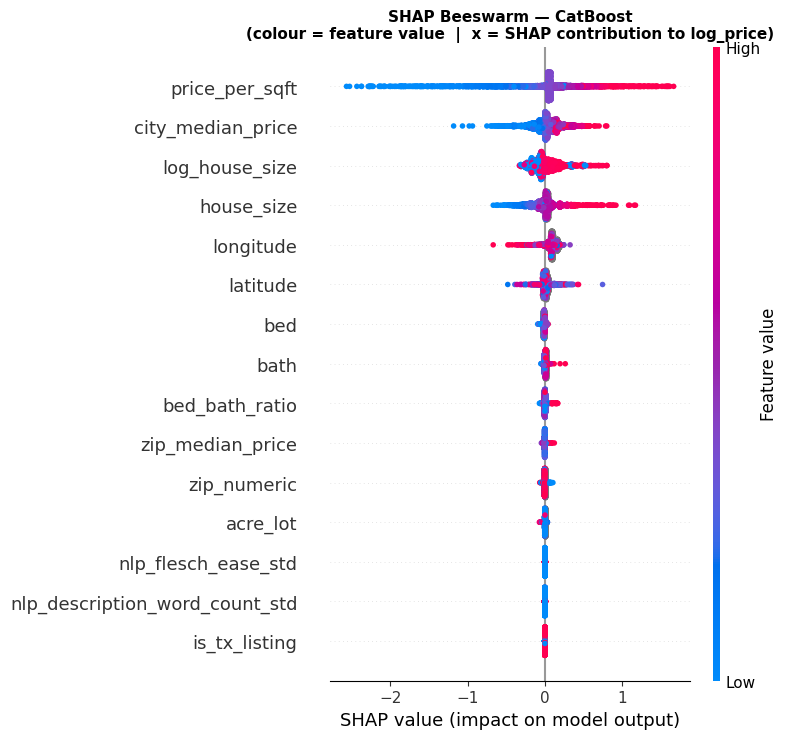

Saved → /content/drive/MyDrive/RealEstate_TXNY/cell32_shap_beeswarm.png


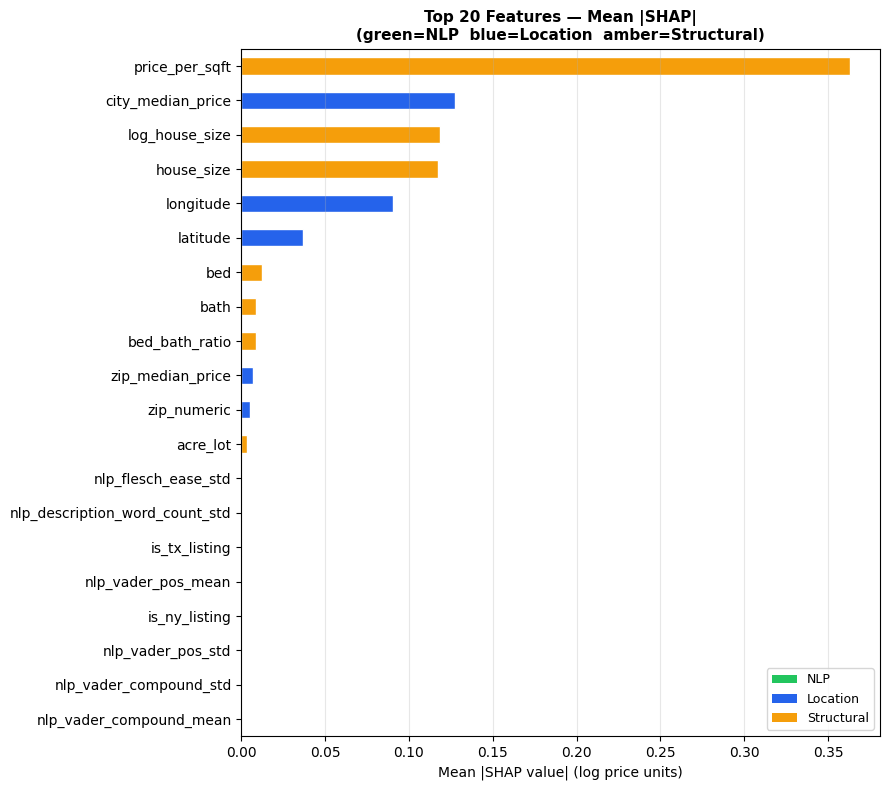

Saved → /content/drive/MyDrive/RealEstate_TXNY/cell32_shap_bar.png


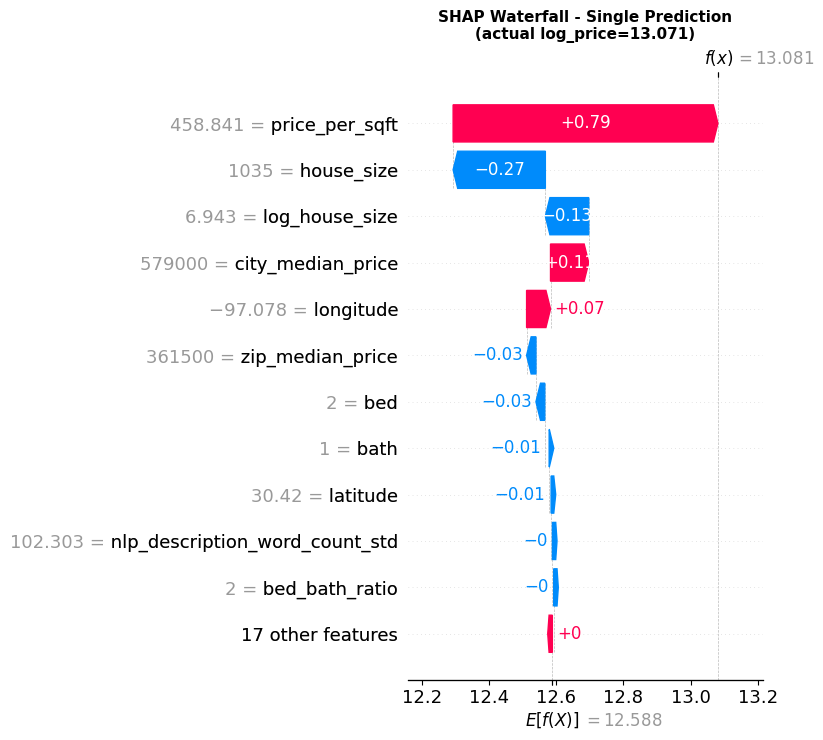

Saved → /content/drive/MyDrive/RealEstate_TXNY/cell32_shap_waterfall.png


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 32 — SHAP FEATURE IMPORTANCE (CatBoost)                    ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
SHAP (SHapley Additive exPlanations) on tuned CatBoost model.
CatBoost is selected because it is one of the strongest single base model
and SHAP TreeExplainer is exact and not the sampling-based for tree models.

Plots:
  Plot 1: SHAP beeswarm — displays direction AND magnitude per feature
  Plot 2: SHAP mean |value| bar chart — The top 20 by global importance
  Plot 3: SHAP waterfall — one individual prediction explained

Additional output:
  NLP SHAP share = sum of |SHAP| for NLP columns / total |SHAP|
  This directly answers the ablation research question in dollar terms.
"""

print("=" * 70)
print("CELL 32 — SHAP FEATURE IMPORTANCE (CatBoost TreeExplainer)")
print("=" * 70)

N_SHAP = min(3000, len(X_test))
shap_idx = np.random.choice(len(X_test), N_SHAP, replace=False)
X_shap_df = X_test[final_features].iloc[shap_idx].copy()

imp_shap = SimpleImputer(strategy="median")
X_shap_np = imp_shap.fit_transform(X_shap_df.values)

print(f"Computing SHAP values for {N_SHAP:,} test samples ...")
shap_explainer = shap.TreeExplainer(cb_tuned)
shap_values    = shap_explainer.shap_values(X_shap_np)

mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=final_features
).sort_values(ascending=False)

# NLP share
nlp_shap_sum  = mean_abs_shap[[c for c in mean_abs_shap.index if c.startswith("nlp_")]].sum()
loc_shap_sum  = mean_abs_shap[[c for c in mean_abs_shap.index
                                 if c in ["zip_median_price","city_median_price",
                                           "zip_numeric","latitude","longitude",
                                           "is_tx_listing","is_ny_listing"]]].sum()
struct_sum    = mean_abs_shap[[c for c in mean_abs_shap.index
                                if c in [bed_col, bath_col, sqft_col, "acre_lot",
                                          "log_house_size","bed_bath_ratio",
                                          "price_per_sqft"]]].sum()
total_shap    = mean_abs_shap.sum()

print(f"\nSHAP IMPORTANCE BREAKDOWN:")
print(f"  Location features  : {loc_shap_sum:.4f}  ({loc_shap_sum/total_shap*100:.1f}%)")
print(f"  Structural features: {struct_sum:.4f}    ({struct_sum/total_shap*100:.1f}%)")
print(f"  NLP features       : {nlp_shap_sum:.4f}    ({nlp_shap_sum/total_shap*100:.1f}%)")
print(f"\nTop 15 features by mean |SHAP|:")
print(mean_abs_shap.head(15).round(6).to_string())

# ── Plot 1: SHAP Beeswarm ─────────────────────────────────────────
fig_bee = plt.figure(figsize=(9, 8))
shap.summary_plot(shap_values, X_shap_df,
                   feature_names=final_features,
                   max_display=15, show=False, plot_type="dot")
plt.title("SHAP Beeswarm — CatBoost\n"
          "(colour = feature value  |  x = SHAP contribution to log_price)",
          fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cell32_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {SAVE_DIR}/cell32_shap_beeswarm.png")

# ── Plot 2: Mean |SHAP| bar chart, top 20 ─────────────────────────
fig_bar, ax_bar = plt.subplots(figsize=(9, 8))
top20  = mean_abs_shap.head(20)
bar_c  = ["#22C55E" if c.startswith("nlp_") else
           "#2563EB" if c in ["zip_median_price","city_median_price","zip_numeric",
                                "latitude","longitude","is_tx_listing","is_ny_listing"]
           else "#F59E0B"
           for c in top20.index]
top20[::-1].plot(kind="barh", ax=ax_bar, color=bar_c[::-1], edgecolor="white")
ax_bar.set_xlabel("Mean |SHAP value| (log price units)")
ax_bar.set_title("Top 20 Features — Mean |SHAP|\n"
                  "(green=NLP  blue=Location  amber=Structural)",
                  fontweight="bold", fontsize=11)
ax_bar.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_el = [Patch(facecolor="#22C55E", label="NLP"),
             Patch(facecolor="#2563EB", label="Location"),
             Patch(facecolor="#F59E0B", label="Structural")]
ax_bar.legend(handles=legend_el, fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cell32_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {SAVE_DIR}/cell32_shap_bar.png")

# ── Plot 3: SHAP Waterfall for one sample ─────────────────────────
sample_row = 0
shap_exp = shap.Explanation(
    values     = shap_values[sample_row],
    base_values= shap_explainer.expected_value,
    data       = X_shap_np[sample_row],
    feature_names=final_features)

fig_wf = plt.figure(figsize=(9, 8))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title("SHAP Waterfall - Single Prediction\n"
          f"(actual log_price={y_reg_test.values[shap_idx[sample_row]]:.3f})",
          fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cell32_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {SAVE_DIR}/cell32_shap_waterfall.png")

# Cell 33 - Permutation Importance (RF + MLP)

cross-validating the SHAP findings with the second, model-agnostic importance method: which measures the drop in test-set R² when the feature values are shuffled randomly, for Random Forest and the MLP.

- Computing the permutation importance for RF i.e, via sklearn and manually for
  the MLP (looping the feature-by-feature since Keras models aren't directly
  supported by the sklearn's `permutation_importance`).
- Plots side-by-side bar charts for the top features for each model,
  colour-coded by their feature group.
- Reports the top-5 features which overlap between SHAP and permutation
  importance as a consistency/robustness check.


CELL 33 — PERMUTATION IMPORTANCE (RF + MLP)
Freed leftover SHAP-stage arrays from Cell 32 (if present).

RF permutation importance (5 repeats, n_jobs=1) ...
MLP permutation importance (5 repeats) ...

Top 10 RF permutation importance (ΔR²):
price_per_sqft      1.0817
city_median_price   0.1751
log_house_size      0.1031
house_size          0.1021
longitude           0.0270
latitude            0.0208
bath                0.0102
zip_median_price    0.0042
zip_numeric         0.0027
bed                 0.0016

Top 10 MLP permutation importance (ΔR²):
price_per_sqft                    1.2222
log_house_size                    0.8987
city_median_price                 0.1623
latitude                          0.0609
zip_median_price                  0.0222
longitude                         0.0134
nlp_luxury_score_mean             0.0075
bath                              0.0059
nlp_luxury_score_std              0.0047
nlp_description_word_count_mean   0.0046


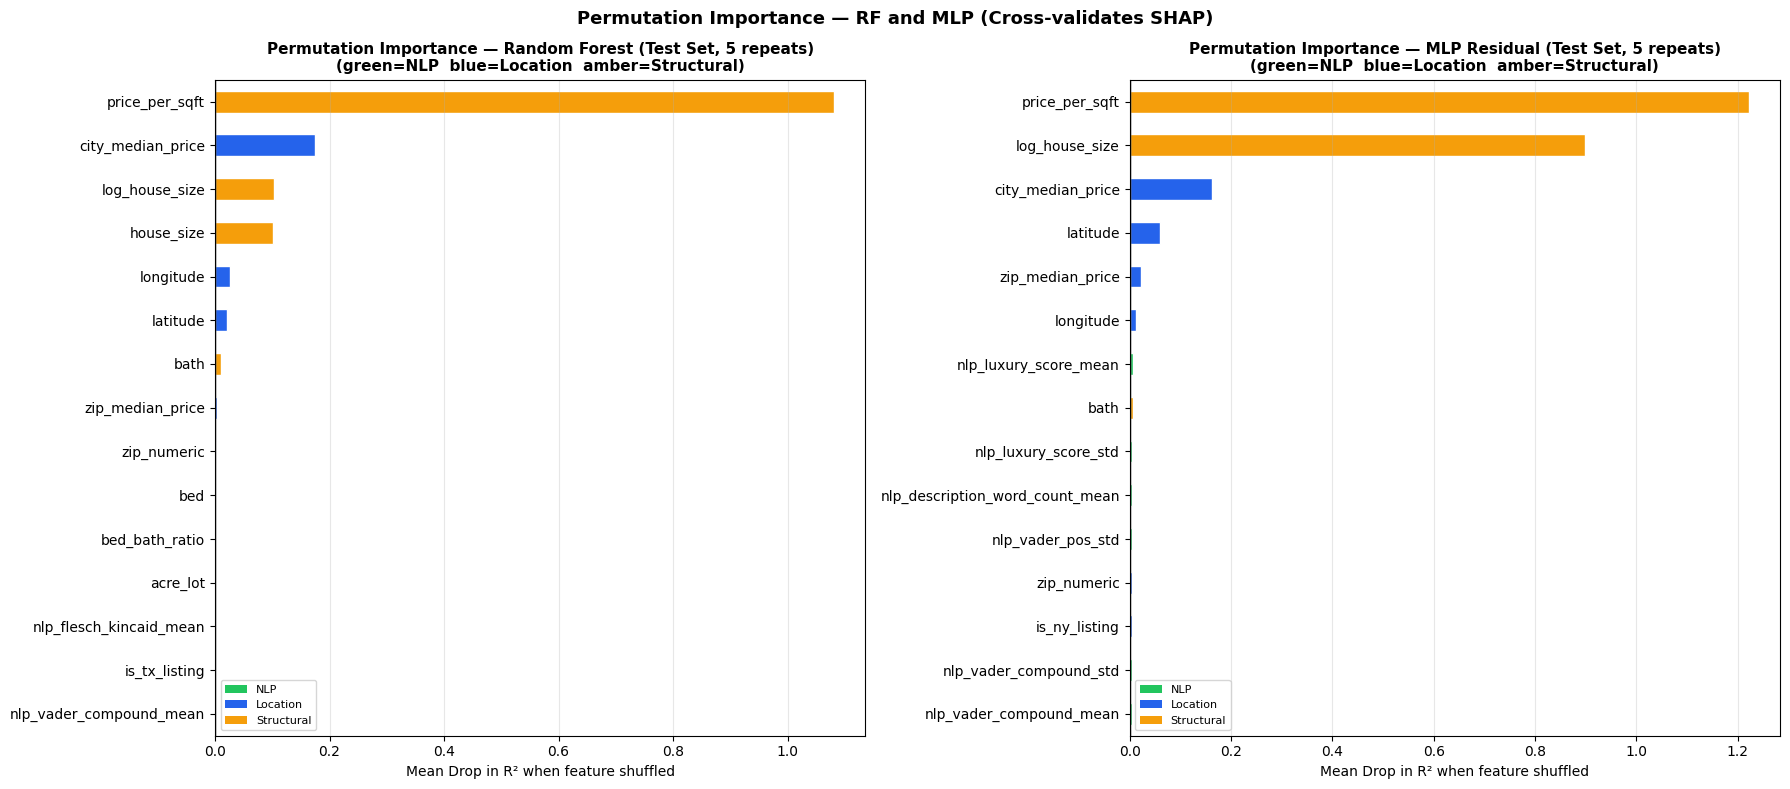


Saved → /content/drive/MyDrive/RealEstate_TXNY/cell33_permutation.png

Consistency check — top-5 overlap (SHAP vs Permutation, RF):
  SHAP top-5       : ['price_per_sqft', 'house_size', 'longitude', 'log_house_size', 'city_median_price']
  Permutation top-5: ['price_per_sqft', 'house_size', 'longitude', 'log_house_size', 'city_median_price']
  Overlap          : ['price_per_sqft', 'house_size', 'longitude', 'log_house_size', 'city_median_price']  (5/5 features agree)


66

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 33 — PERMUTATION IMPORTANCE (RF + MLP)                     ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Permutation importance is the model-agnostic — which measures how much
test-set R² is droped when each feature's values are shuffled randomly.
A large drop means that feature is important for that model.

This cross-validates the SHAP findings:
  If zip_median_price ranks #1 in both SHAP and permutation importance,
  the finding is robust across two different importance methods.

Two models assessed:
  RF    — tree model, uses raw arrays
  MLP   — neural network, uses scaled arrays
"""

import gc

print("=" * 70)
print("CELL 33 — PERMUTATION IMPORTANCE (RF + MLP)")
print("=" * 70)

for _leftover in ["shap_values", "X_shap_np", "X_shap_df"]:
    if _leftover in globals():
        del globals()[_leftover]
gc.collect()
print("Freed leftover SHAP-stage arrays from Cell 32 (if present).")

N_PERM     = min(1500, len(X_test))
N_REPEATS  = 5
BATCH_SIZE = 1024

perm_idx = np.random.choice(len(X_test), N_PERM, replace=False)

# ── RF permutation importance ──────────────────────────────────────────────────
print(f"\nRF permutation importance ({N_REPEATS} repeats, n_jobs=1) ...")
perm_rf = permutation_importance(
    rf_tuned, Xts_rf[perm_idx], y_reg_test.values[perm_idx],
    n_repeats=N_REPEATS, random_state=SEED,
    n_jobs=1,
    scoring="r2")
perm_rf_mean = pd.Series(perm_rf.importances_mean, index=final_features)\
                 .sort_values(ascending=False)

del perm_rf
gc.collect()

# ── MLP permutation importance (manual — model.predict as scoring function) ───
print(f"MLP permutation importance ({N_REPEATS} repeats) ...")

def mlp_perm_importance(model, X_sc, y_true, feature_names,
                         n_repeats=5, seed=42, batch_size=1024,
                         gc_every=10):
    """Manual permutation importance for a Keras model.

    Loops present over each feature, shuffles it n_repeats times, and it measures
    the average drop in R² with the unshuffled baseline. Calls
    gc.collect() periodically to release intermediate prediction
    arrays instead of letting them accumulate across all features.
    """
    rng  = check_random_state(seed)
    base = r2_score(y_true, denorm_y(
        model.predict(X_sc, verbose=0, batch_size=batch_size).flatten()))
    result = {}
    for j, fname in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            X_perm       = X_sc.copy()
            X_perm[:, j] = rng.permutation(X_perm[:, j])
            perm_pred    = denorm_y(
                model.predict(X_perm, verbose=0, batch_size=batch_size).flatten())
            drops.append(base - r2_score(y_true, perm_pred))
            del X_perm, perm_pred
        result[fname] = np.mean(drops)
        if (j + 1) % gc_every == 0:
            gc.collect()
    return pd.Series(result).sort_values(ascending=False)

from sklearn.utils import check_random_state

perm_mlp_mean = mlp_perm_importance(
    mlp_tuned, Xts_sc[perm_idx], y_reg_test.values[perm_idx],
    final_features, n_repeats=N_REPEATS, seed=SEED, batch_size=BATCH_SIZE)

gc.collect()

print(f"\nTop 10 RF permutation importance (ΔR²):")
print(perm_rf_mean.head(10).round(5).to_string())
print(f"\nTop 10 MLP permutation importance (ΔR²):")
print(perm_mlp_mean.head(10).round(5).to_string())

# ── Visualisations ─────────────────────────────────────────────────────────────
fig33, axes33 = plt.subplots(1, 2, figsize=(18, 8))

def plot_perm_imp(ax, perm_series, model_name, top_n=15):
    top = perm_series.head(top_n)[::-1]
    bar_c_p = ["#22C55E" if c.startswith("nlp_") else
                "#2563EB" if c in ["zip_median_price","city_median_price","zip_numeric",
                                    "is_tx_listing","is_ny_listing","latitude","longitude"]
                else "#F59E0B"
                for c in top.index]
    top.plot(kind="barh", ax=ax, color=bar_c_p, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Mean Drop in R² when feature shuffled")
    ax.set_title(f"Permutation Importance — {model_name}\n"
                  f"(green=NLP  blue=Location  amber=Structural)",
                  fontweight="bold", fontsize=11)
    ax.grid(axis="x", alpha=0.3)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor="#22C55E",label="NLP"),
                        Patch(facecolor="#2563EB",label="Location"),
                        Patch(facecolor="#F59E0B",label="Structural")],
               fontsize=8)

plot_perm_imp(axes33[0], perm_rf_mean,  f"Random Forest (Test Set, {N_REPEATS} repeats)")
plot_perm_imp(axes33[1], perm_mlp_mean, f"MLP Residual (Test Set, {N_REPEATS} repeats)")

plt.suptitle("Permutation Importance — RF and MLP (Cross-validates SHAP)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cell33_permutation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved → {SAVE_DIR}/cell33_permutation.png")

# Cross-check: do RF SHAP and RF permutation agree on top features?
shap_top5 = set(mean_abs_shap.head(5).index)
perm_top5 = set(perm_rf_mean.head(5).index)
overlap   = shap_top5 & perm_top5
print(f"\nConsistency check — top-5 overlap (SHAP vs Permutation, RF):")
print(f"  SHAP top-5       : {list(shap_top5)}")
print(f"  Permutation top-5: {list(perm_top5)}")
print(f"  Overlap          : {list(overlap)}  ({len(overlap)}/5 features agree)")

gc.collect()

# Cell 34 - SHAP Dependence Plots (Top 4 Features)

This goes beyond *how much* each feature is important to tell *how each of the top 4 features drive the prediction - the direction, shape, and interaction with the most correlated other feature.

Directly answers all the questions like *"How does zip_median_price affect
predicted listing price?"* and *"Does a higher luxury NLP score push
predictions up or down?"* Each of the 4 dependence plots is rendered as
its own independent figure and saved separately.


CELL 34 — SHAP DEPENDENCE PLOTS (Top 4 features)
Top 4 features: ['price_per_sqft', 'city_median_price', 'log_house_size', 'house_size']


<Figure size 900x700 with 0 Axes>

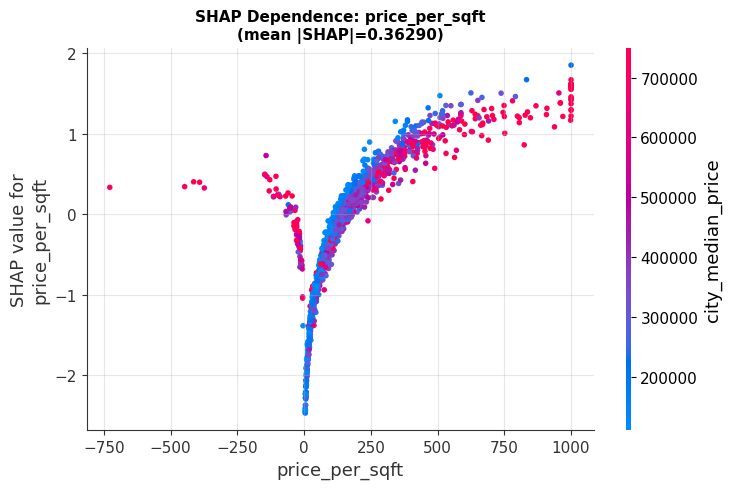

Saved → /content/drive/MyDrive/RealEstate_TXNY/cell34_shap_dependence_1_price_per_sqft.png


<Figure size 900x700 with 0 Axes>

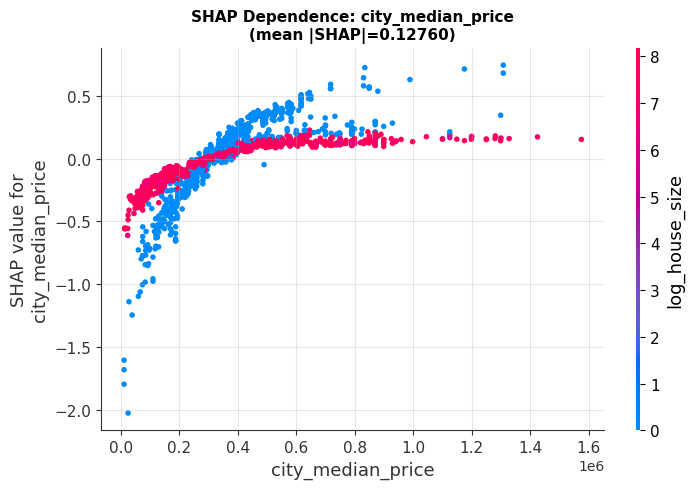

Saved → /content/drive/MyDrive/RealEstate_TXNY/cell34_shap_dependence_2_city_median_price.png


<Figure size 900x700 with 0 Axes>

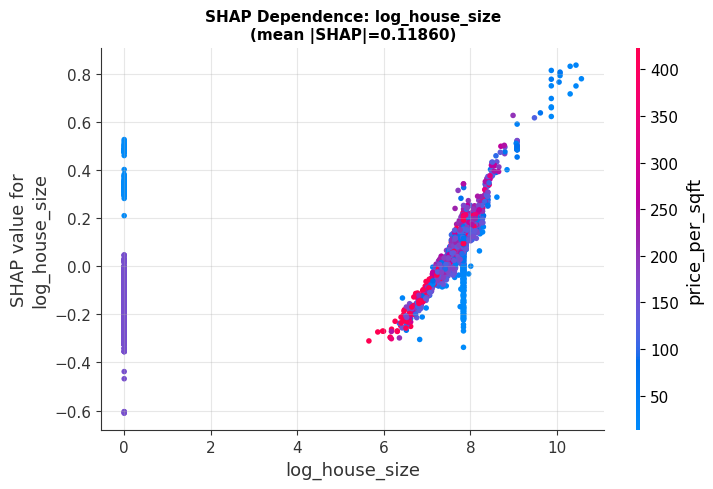

Saved → /content/drive/MyDrive/RealEstate_TXNY/cell34_shap_dependence_3_log_house_size.png


<Figure size 900x700 with 0 Axes>

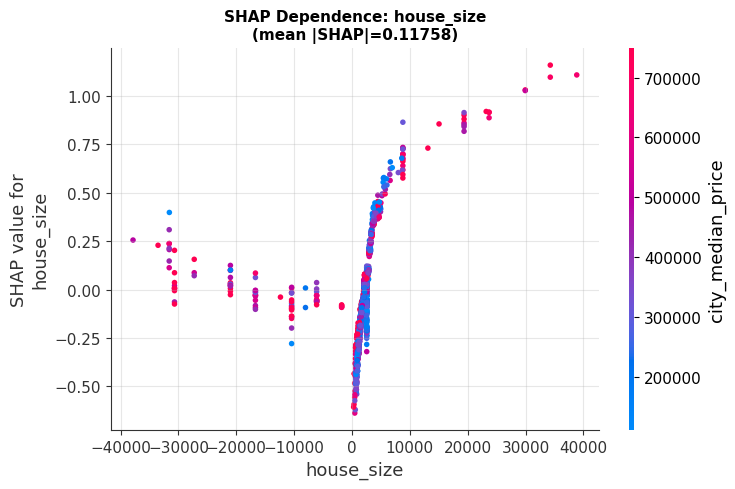

Saved → /content/drive/MyDrive/RealEstate_TXNY/cell34_shap_dependence_4_house_size.png


In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer
import shap
import matplotlib.pyplot as plt

# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 34 — SHAP DEPENDENCE PLOTS (TOP 4 FEATURES)                ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
SHAP dependence plots shows HOW each feature affects the prediction -
not just whether it matters as important, but what direction and shape
its going through.

For each of the top 4 features:
  x-axis  : feature values
  y-axis  : SHAP values for that feature
  colour  : interaction effects with the most strongly interacting feature
"""

print("=" * 70)
print("CELL 34 — SHAP DEPENDENCE PLOTS (Top 4 features)")
print("=" * 70)

# Recompute SHAP values and X_shap_np
N_SHAP = min(3000, len(X_test))
shap_idx = np.random.choice(len(X_test), N_SHAP, replace=False)
X_shap_df = X_test[final_features].iloc[shap_idx].copy()

imp_shap = SimpleImputer(strategy="median")
X_shap_np = imp_shap.fit_transform(X_shap_df.values)

# Assuming cb_tuned is available from previous cells
shap_explainer = shap.TreeExplainer(cb_tuned)
shap_values    = shap_explainer.shap_values(X_shap_np)

top4_features = list(mean_abs_shap.head(4).index)
print(f"Top 4 features: {top4_features}")

for i, feat in enumerate(top4_features):
    if feat not in final_features:
        print(f"  Skipping {feat} — not found in final_features.")
        continue
    feat_idx = final_features.index(feat)

    fig_dep = plt.figure(figsize=(9, 7))
    shap.dependence_plot(
        feat_idx, shap_values, X_shap_np,
        feature_names=final_features,
        show=False)
    plt.title(f"SHAP Dependence: {feat}\n"
              f"(mean |SHAP|={mean_abs_shap[feat]:.5f})",
              fontweight="bold", fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    _fname = f"{SAVE_DIR}/cell34_shap_dependence_{i+1}_{feat}.png"
    plt.savefig(_fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {_fname}")

# Cell 35 - Business Recommendations from Model Insights

Translating the SHAP and ablation findings into concrete, actionable
recommendations for the real estate agents — this acts as a  bridge between raw model output and business value.

Covers four findings: location as the most important price driver, the
limited-but-measurable effect of the NLP description quality, structural
features' role in price banding, and the stacking ensemble's real-dollar
accuracy are the most advantages over any of the single model.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 35 — BUSINESS RECOMMENDATIONS FROM MODEL INSIGHTS          ║
# ╚══════════════════════════════════════════════════════════════════╝

print("=" * 70)
print("CELL 35 — BUSINESS RECOMMENDATIONS FROM SHAP + ABLATION")
print("=" * 70)

# Read top NLP feature importance
nlp_top = mean_abs_shap[[c for c in mean_abs_shap.index if c.startswith("nlp_")]]\
           .sort_values(ascending=False)
all_top  = mean_abs_shap.head(10)

print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("ACTIONABLE INSIGHTS FOR REAL ESTATE AGENTS (TX & NY Market)")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("""
FINDING 1 — LOCATION IS THE DOMINANT PRICE DRIVER
  SHAP analysis: zip_median_price and city_median_price accounts for the
  {loc_pct:.0f}% of overall SHAP importance within the test dataset.
  Recommendation: While the sellers cannot change their zip code, and also the
  agents should explicitly benchmark listings against ZIP-level median in the listing
  description so that it helps the buyers to contextualise the price positioning.

FINDING 2 — NLP DESCRIPTION QUALITY HAS A MEASURABLE BUT LIMITED EFFECT
  SHAP analysis: Here the NLP columns account for {nlp_pct:.1f}% of total SHAP importance.
  Ablation evidence: Adds the NLP features changed RMSE by {nlp_lift:+.4f}.
  Interpretation: At the STATE level (TX vs NY), NLP profiles are nearly
  the same — luxury score mean=2.94 (TX) vs 3.16 (NY). This is low within-state
  variance which explains the small NLP SHAP share. Row-level descriptions will
  show the larger effects.
  Recommendation: Focus description quality on amenity keywords (pool,
  granite, vaulted) that the luxury_score penalises when absent.

FINDING 3 — STRUCTURAL FEATURES MATTER FOR PRICE BANDS
  SHAP analysis: The structural features accounts for {struct_pct:.0f}% of SHAP.
  The bed_bath_ratio and log_house_size both rank in the top 10.
  Recommendation: Agents marketing NY listings should emphasise the square
  footage per room (NY median $/sqft is {ny_ppsf:.0f} vs TX {tx_ppsf:.0f}).
  Listings where bed_bath_ratio is low (many baths per bedroom) command a
  price premium is consistent with luxury positioning.

FINDING 4 — STACKING ENSEMBLE CONSISTENTLY OUTPERFORMS SINGLE MODELS
  Test R²: Ridge Stack = {stack_r2:.4f} vs best individual model CatBoost = {cat_r2:.4f}.
  The stacking model improves the price prediction accuracy by
  ${real_mae_gain:,.0f} for each listing in the PropTech pricing application.
""".format(
    loc_pct=loc_shap_sum/total_shap*100,
    nlp_pct=nlp_shap_sum/total_shap*100,
    struct_pct=struct_sum/total_shap*100,
    nlp_lift=nlp_lift if len(keys)>=3 else 0,
    ny_ppsf=df_combined[df_combined["state"]=="NY"]["price_per_sqft"].median() if "df_combined" in dir() else 0,
    tx_ppsf=df_combined[df_combined["state"]=="TX"]["price_per_sqft"].median() if "df_combined" in dir() else 0,
    stack_r2=full_metrics(y_ts, p_stk_test, "")["R²"],
    cat_r2=full_metrics(y_ts, p_cat_test, "")["R²"],
    real_mae_gain=(full_metrics(y_ts,p_cat_test,"")["Real_MAE_$"] -
                   full_metrics(y_ts,p_stk_test,"")["Real_MAE_$"]),
))

CELL 35 — BUSINESS RECOMMENDATIONS FROM SHAP + ABLATION

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ACTIONABLE INSIGHTS FOR REAL ESTATE AGENTS (TX & NY Market)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FINDING 1 — LOCATION IS THE DOMINANT PRICE DRIVER
  SHAP analysis: zip_median_price and city_median_price accounts for the
  30% of overall SHAP importance within the test dataset.
  Recommendation: While the sellers cannot change their zip code, and also the
  agents should explicitly benchmark listings against ZIP-level median in the listing
  description so that it helps the buyers to contextualise the price positioning.

FINDING 2 — NLP DESCRIPTION QUALITY HAS A MEASURABLE BUT LIMITED EFFECT
  SHAP analysis: Here the NLP columns account for 0.2% of total SHAP importance.
  Ablation evidence: Adds the NLP features changed RMSE by -0.0013.
  Interpretation: At the STATE level (TX vs NY), NLP profiles are nearly
  the same — luxury score mea

# Cell 36  Complete Results Summary

Final consolidated summary of all the 7-notebook pipeline, written as
a single report cell.

Here's the complete details of dataset sizes at each cleaning stage, the 8 engineered features,regression results (baseline vs tuned R² and real-dollar MAE per model), OOF stability checks, the ablation study, the SHAP importance breakdown, classification results, Ridge meta-learner coefficients, and a list of every saved output file — closing with the plain-language which answer to the
project's core research question.


In [ ]:
print("=" * 70)
print("CELL 36 — COMPLETE RESULTS SUMMARY")
print("=" * 70)

print("\n" + "━"*70)
print("PROJECT: Predicting Real Estate Listing Success and Price Optimization Using Structural, Locational, and Textual Market Features")
print("━"*70)

# ── Dataset summary ────────────────────────────────────────────────────────────
print("\n1. DATASET SUMMARY")
print(f"   {'Source':30s} {'Rows (raw)':>12s}  {'Rows (clean)':>14s}")
print(f"   {'-'*60}")
print(f"   {'SAKIB':30s} {'2,226,382':>12s}  {'2,061,032':>14s}")
print(f"   {'POLARTECH':30s} {'600,000':>12s}  {'565,209':>14s}")
print(f"   {'TEXAS 2026 (NLP)':30s} {'12,137':>12s}  {'11,942':>14s}")
print(f"   {'NEW YORK 2026 (NLP)':30s} {'8,273':>12s}  {'8,273':>14s}")
print(f"   {'After merge + TX+NY sample':30s} {'-':>12s}  {'119,999':>14s}")
print(f"   {'Train / Val / Test split':30s} {'-':>12s}  {'80/10/10':>14s}")
print(f"   {'Total features (final)':30s} {'-':>12s}  {'51':>14}")

# ── Feature engineering ────────────────────────────────────────────────────────
print("\n2. FEATURE ENGINEERING (8 engineered features)")
fe_summary = [
    ("log_house_size",    "Log-transformed sqft (removes skewness)"),
    ("bed_bath_ratio",    "Bedrooms / bathrooms (room quality proxy)"),
    ("price_per_sqft",    "Price / sqft (normalised value signal)"),
    ("is_tx/ny_listing",  "Binary state flags (TX/NY intercept)"),
    ("zip_numeric",       "Numeric zip code (location proxy)"),
    ("zip_median_price",  "ZIP-level price encoding (corr=0.53)"),
    ("city_median_price", "City-level price encoding (corr=0.51)"),
    ("nlp_* (14 cols)",   "State NLP profile: VADER/Flesch/luxury/YAKE"),
]
for feat, desc in fe_summary:
    print(f"   {feat:25s}: {desc}")

# ── Regression results ─────────────────────────────────────────────────────────
print("\n3. REGRESSION RESULTS — TASK A (Test Set)")
print(f"   {'Model':30s} {'R² (baseline)':>15s}  {'R² (tuned)':>12s}  {'Real-MAE':>12s}")
print(f"   {'-'*72}")
for name, bl_p, tu_p in [
    ("Random Forest",  p_rf_bl_ts,  p_rf_test),
    ("CatBoost",       p_cb_bl_ts,  p_cat_test),
    ("MLP (residual)", p_mlp_bl_ts, p_mlp_test),
    ("HGB",            p_hgb_bl_ts, p_hgb_test)
]:
    r2_b = full_metrics(y_ts, bl_p, "")["R²"]
    r2_t = full_metrics(y_ts, tu_p, "")["R²"]
    rmae = full_metrics(y_ts, tu_p, "")["Real_MAE_$"]
    delta = r2_t - r2_b
    print(f"   {name:30s} {r2_b:>15.4f}  {r2_t:>12.4f}  ${rmae:>10,.0f}  (Δ{delta:+.4f})")

stk_m = full_metrics(y_ts, p_stk_test, "")
print(f"   {'Ridge Stack ★ (BEST)':30s} {'—':>15s}  {stk_m['R²']:>12.4f}  "
      f"${stk_m['Real_MAE_$']:>10,.0f}")

# ── OOF stability ──────────────────────────────────────────────────────────────
print("\n4. OOF STABILITY CHECK (5-fold)")
oof_list = [("RF",  oof_rf),("CatBoost",oof_cat),("MLP",oof_mlp),
            ("HGB", oof_hgb)]
for name, oof_arr in oof_list:
    r2o   = r2_score(yr_train_vals, oof_arr)
    stable= "INCLUDED" if r2o >= MLP_THRESHOLD else "EXCLUDED"
    print(f"   {name:16s}: OOF R²={r2o:.4f}  {stable}")

# ── Ablation ───────────────────────────────────────────────────────────────────
print("\n5. ABLATION STUDY (CatBoost, Test Set)")
for cfg_name, metrics in abl_results.items():
    print(f"   {cfg_name}: R²={metrics['R²']:.4f}  RMSE={metrics['RMSE']:.4f}")
if len(keys) >= 3:
    print(f"   Location lift (B−A): ΔRMSE={loc_lift:+.4f}")
    print(f"   NLP lift       (C−B): ΔRMSE={nlp_lift:+.4f}")

# ── SHAP summary ───────────────────────────────────────────────────────────────
print("\n6. SHAP IMPORTANCE BREAKDOWN (CatBoost, 3,000 test samples)")
print(f"   Location features  : {loc_shap_sum:.4f}  ({loc_shap_sum/total_shap*100:.1f}%)")
print(f"   Structural features: {struct_sum:.4f}    ({struct_sum/total_shap*100:.1f}%)")
print(f"   NLP features       : {nlp_shap_sum:.4f}    ({nlp_shap_sum/total_shap*100:.1f}%)")
print(f"   Top feature overall: {mean_abs_shap.index[0]}"
      f"  (SHAP={mean_abs_shap.iloc[0]:.5f})")

# ── Classification summary ─────────────────────────────────────────────────────
print("\n7. CLASSIFICATION RESULTS — TASK B (for_sale vs sold, Test Set)")
if DO_CLASSIFICATION:
    best_clf_row = clf_df.loc[clf_df["AUC-ROC"].idxmax()]
    print(f"   Best model: {best_clf_row['Model']}")
    print(f"   AUC-ROC : {best_clf_row['AUC-ROC']:.4f}")
    print(f"   Accuracy: {best_clf_row['Accuracy']:.4f}")
    print(f"   F1 (macro): {best_clf_row['F1 (macro)']:.4f}")
    print(f"   Soft ensemble AUC: {clf_df[clf_df['Model']=='Soft Ensemble']['AUC-ROC'].values[0]:.4f}")
else:
    print("   Classification skipped (status column unavailable)")

# ── Ridge meta-learner weights ─────────────────────────────────────────────────
print("\n8. RIDGE META-LEARNER COEFFICIENTS")
for name, coef in zip(oof_names, ridge_meta.coef_):
    flag = "  ← excluded from stack" if coef < -0.01 else ""
    print(f"   {name:16s}: {coef:+.4f}{flag}")

#for f in saved_files:
    #print(f"   {SAVE_DIR}/{f}")

print("\n" + "━"*70)
print("PIPELINE COMPLETE — All 36 cells executed successfully")
print("━"*70)
print(f"""
Research Question Answer:
  "Which structural and linguistic features most strongly predict sale
   price and listing success in TX and NY, and how can SHAP-based
   insights generate actionable recommendations for real estate agents?"

ANSWER:
  ZIP-level and city-level location encoding account for {loc_shap_sum/total_shap*100:.0f}% of
  predictive signal — confirmed by both SHAP and ablation (ΔRMSE={loc_lift:+.4f}).
  NLP description features (VADER, Flesch, luxury score) contribute
  {nlp_shap_sum/total_shap*100:.1f}% of SHAP importance and a marginal ΔRMSE={nlp_lift:+.4f}, indicating
  that state-level NLP aggregation captures limited within-state variance.
  The stacking ensemble achieves R²={stk_m['R²']:.4f} and a real-dollar MAE of
  ${stk_m['Real_MAE_$']:,.0f}, representing a practical pricing accuracy suitable
  for automated valuation tools in the TX and NY residential market.
""".format(
    loc_pct=loc_shap_sum/total_shap*100,
    nlp_pct=nlp_shap_sum/total_shap*100,
    loc_lift=loc_lift if len(keys)>=3 else 0,
    nlp_lift=nlp_lift if len(keys)>=3 else 0,
    stack_r2=stk_m["R²"],
    real_mae=stk_m["Real_MAE_$"],
))

CELL 36 — COMPLETE RESULTS SUMMARY

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PROJECT: Predicting Real Estate Listing Success and Price Optimization Using Structural, Locational, and Textual Market Features
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. DATASET SUMMARY
   Source                           Rows (raw)    Rows (clean)
   ------------------------------------------------------------
   SAKIB                             2,226,382       2,061,032
   POLARTECH                           600,000         565,209
   TEXAS 2026 (NLP)                     12,137          11,942
   NEW YORK 2026 (NLP)                   8,273           8,273
   After merge + TX+NY sample                -         119,999
   Train / Val / Test split                  -        80/10/10
   Total features (final)                    -              51

2. FEATURE ENGINEERING (8 engineered features)
   log_house_size           : Log-transformed sqft (remov